## Cell 1 — complete setup

In [33]:
import pandas as pd
import numpy as np
import pandas_gbq

# -----------------------------
# LOAD DATA
# -----------------------------

query = """
SELECT *
FROM `amplified-alpha-463610-c8.ecommerce_ml.session_features`
"""

df = pandas_gbq.read_gbq(
    query,
    project_id="amplified-alpha-463610-c8",
    dialect="standard"
)

print("Loaded:", df.shape)

# -----------------------------
# FEATURE ENGINEERING
# -----------------------------

data = df.copy()

data["session_date"] = pd.to_datetime(data["session_date"])

data["has_cart"] = (data["add_to_cart_5min"] > 0).astype(int)
data["has_checkout"] = (data["begin_checkout_5min"] > 0).astype(int)
data["has_product_view"] = (data["product_views_5min"] > 0).astype(int)
data["has_product_click"] = (data["product_clicks_5min"] > 0).astype(int)

data["is_returning_user"] = 1 - data["is_new_user"]

data["product_views_per_page"] = (
    data["product_views_5min"] /
    data["page_views_5min"].replace(0, np.nan)
)

data["click_per_product_view"] = (
    data["product_clicks_5min"] /
    data["product_views_5min"].replace(0, np.nan)
)

data["cart_per_product_view"] = (
    data["add_to_cart_5min"] /
    data["product_views_5min"].replace(0, np.nan)
)

ratio_cols = [
    "product_views_per_page",
    "click_per_product_view",
    "cart_per_product_view"
]

data[ratio_cols] = (
    data[ratio_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

data["day_of_week"] = data["session_date"].dt.dayofweek
data["is_weekend"] = data["day_of_week"].isin([5, 6]).astype(int)

categorical_features = [
    "device_category",
    "operating_system",
    "traffic_source",
    "traffic_medium"
]

for col in categorical_features:
    data[col] = data[col].fillna("unknown")

# -----------------------------
# TIME SPLIT
# -----------------------------

train = data[
    data["session_date"] <= "2020-12-15"
].copy()

validation = data[
    (data["session_date"] >= "2020-12-16") &
    (data["session_date"] <= "2021-01-07")
].copy()

test = data[
    data["session_date"] >= "2021-01-08"
].copy()

# -----------------------------
# FEATURES
# -----------------------------

numeric_features = [
    "total_events_5min",
    "page_views_5min",
    "product_views_5min",
    "product_clicks_5min",
    "add_to_cart_5min",
    "begin_checkout_5min",
    "search_events_5min",
    "is_returning_user",
    "has_cart",
    "has_checkout",
    "has_product_view",
    "has_product_click",
    "product_views_per_page",
    "click_per_product_view",
    "cart_per_product_view",
    "is_weekend"
]

feature_columns = numeric_features + categorical_features

# -----------------------------
# X / y
# -----------------------------

X_train = train[feature_columns]
y_train = train["target"]

X_val = validation[feature_columns]
y_val = validation["target"]

X_test = test[feature_columns]
y_test = test["target"]

print("\nTrain:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

print("\ny_train exists:", len(y_train))

Downloading: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████|
Loaded: (359603, 18)

Train: (184148, 20) (184148,)
Validation: (83529, 20) (83529,)
Test: (91926, 20) (91926,)

y_train exists: 184148


## Cell 2 — Dummy Classifier

In [34]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

dummy = DummyClassifier(strategy="prior")

dummy.fit(
    np.zeros((len(y_train), 1)),
    y_train
)

dummy_val_prob = dummy.predict_proba(
    np.zeros((len(y_val), 1))
)[:, 1]

dummy_roc_auc = roc_auc_score(
    y_val,
    dummy_val_prob
)

dummy_pr_auc = average_precision_score(
    y_val,
    dummy_val_prob
)

print("Dummy ROC-AUC:", dummy_roc_auc)
print("Dummy PR-AUC:", dummy_pr_auc)

Dummy ROC-AUC: 0.5
Dummy PR-AUC: 0.0087873672616696


## Cell 3 — Logistic Regression

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

preprocessor = ColumnTransformer([
    (
        "num",
        StandardScaler(),
        numeric_features
    ),
    (
        "cat",
        OneHotEncoder(handle_unknown="ignore"),
        categorical_features
    )
])

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(max_iter=1000)
    )
])

logistic_model.fit(
    X_train,
    y_train
)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [36]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss
)

# Predict purchase probabilities
val_prob = logistic_model.predict_proba(X_val)[:, 1]

# Metrics
roc_auc = roc_auc_score(y_val, val_prob)
pr_auc = average_precision_score(y_val, val_prob)
logloss = log_loss(y_val, val_prob)
brier = brier_score_loss(y_val, val_prob)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")
print(f"Log Loss: {logloss:.4f}")
print(f"Brier Score: {brier:.4f}")

ROC-AUC: 0.9518
PR-AUC: 0.2723
Log Loss: 0.0305
Brier Score: 0.0075


In [37]:
results = pd.DataFrame({
    "Model": [
        "Dummy",
        "Logistic Regression"
    ],
    "ROC_AUC": [
        dummy_roc_auc,
        roc_auc
    ],
    "PR_AUC": [
        dummy_pr_auc,
        pr_auc
    ]
})

results

,Model,ROC_AUC,PR_AUC
0,Dummy,0.50000,0.008787
1,Logistic Regression,0.95184,0.272267


In [38]:
prediction_check = X_val.copy()

prediction_check["actual_purchase"] = y_val.values
prediction_check["purchase_probability"] = val_prob

prediction_check[
    [
        "product_views_5min",
        "add_to_cart_5min",
        "begin_checkout_5min",
        "is_returning_user",
        "actual_purchase",
        "purchase_probability"
    ]
].sort_values(
    "purchase_probability",
    ascending=False
).head(20)

,product_views_5min,add_to_cart_5min,begin_checkout_5min,is_returning_user,actual_purchase,purchase_probability
217268,28,29,0,1,1,0.995185
29457,2,1,15,1,1,0.973635
278734,24,20,0,1,1,0.966039
158175,23,22,0,1,0,0.964940
247715,50,0,0,0,0,0.956482
288324,6,5,4,1,0,0.954672
86534,2,2,8,1,0,0.947655
223257,4,3,6,1,1,0.909790
32647,3,1,3,1,0,0.907436
14422,10,13,2,1,0,0.903372


In [39]:
val_results = pd.DataFrame({
    "actual": y_val.values,
    "probability": val_prob
})

val_results = val_results.sort_values(
    "probability",
    ascending=False
)

top_10_n = int(len(val_results) * 0.10)

top_10 = val_results.head(top_10_n)

overall_conversion_rate = val_results["actual"].mean()

top_10_conversion_rate = top_10["actual"].mean()

lift_at_10 = (
    top_10_conversion_rate /
    overall_conversion_rate
)

print(
    f"Overall Conversion Rate: "
    f"{overall_conversion_rate * 100:.3f}%"
)

print(
    f"Top 10% Conversion Rate: "
    f"{top_10_conversion_rate * 100:.3f}%"
)

print(
    f"Lift@10%: {lift_at_10:.2f}x"
)

Overall Conversion Rate: 0.879%
Top 10% Conversion Rate: 7.830%
Lift@10%: 8.91x


In [40]:
precision_at_10 = top_10["actual"].mean()

recall_at_10 = (
    top_10["actual"].sum()
    / val_results["actual"].sum()
)

print(
    f"Precision@10%: "
    f"{precision_at_10 * 100:.2f}%"
)

print(
    f"Recall@10%: "
    f"{recall_at_10 * 100:.2f}%"
)

print(
    f"Conversions in top 10%: "
    f"{top_10['actual'].sum()}"
)

print(
    f"Total conversions: "
    f"{val_results['actual'].sum()}"
)

Precision@10%: 7.83%
Recall@10%: 89.10%
Conversions in top 10%: 654
Total conversions: 734


## calculate multiple targeting levels

In [41]:
def calculate_lift_table(y_true, probabilities, percentages):
    
    results = pd.DataFrame({
        "actual": np.asarray(y_true),
        "probability": probabilities
    }).sort_values(
        "probability",
        ascending=False
    )

    baseline_rate = results["actual"].mean()
    rows = []

    for pct in percentages:

        n = max(
            1,
            int(len(results) * pct)
        )

        selected = results.head(n)

        precision = selected["actual"].mean()

        recall = (
            selected["actual"].sum()
            / results["actual"].sum()
        )

        lift = (
            precision / baseline_rate
        )

        rows.append({
            "Top_Percent": pct * 100,
            "Sessions_Targeted": n,
            "Conversion_Rate_%": precision * 100,
            "Recall_%": recall * 100,
            "Lift": lift
        })

    return pd.DataFrame(rows)


lift_table = calculate_lift_table(
    y_val,
    val_prob,
    [
        0.01,
        0.05,
        0.10,
        0.20,
        0.30
    ]
)

lift_table

,Top_Percent,Sessions_Targeted,Conversion_Rate_%,Recall_%,Lift
0,1.0,835,33.293413,37.874659,37.887813
1,5.0,4176,13.649425,77.656676,15.533009
2,10.0,8352,7.830460,89.100817,8.911042
3,20.0,16705,4.130500,94.005450,4.700498
4,30.0,25058,2.813473,96.049046,3.201724


In [42]:
# Get feature names after preprocessing
feature_names = logistic_model[
    "preprocessor"
].get_feature_names_out()

# Logistic Regression coefficients
coefficients = logistic_model[
    "classifier"
].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df = coef_df.sort_values(
    "coefficient",
    ascending=False
)

coef_df.head(15)

,feature,coefficient
10,num__has_product_view,0.854795
0,num__total_events_5min,0.808379
7,num__is_returning_user,0.497057
8,num__has_cart,0.096944
9,num__has_checkout,0.075621
2,num__product_views_5min,0.049151
13,num__click_per_product_view,0.043442
4,num__add_to_cart_5min,0.031649
12,num__product_views_per_page,0.025064
15,num__is_weekend,0.022850


In [43]:
coef_df.tail(15)

,feature,coefficient
23,cat__operating_system_Windows,-0.519158
29,cat__traffic_source_shop.googlemerchandisestor...,-0.526510
21,cat__operating_system_Macintosh,-0.532404
25,cat__traffic_source_(data deleted),-0.570715
24,cat__operating_system_iOS,-0.574523
35,cat__traffic_medium_referral,-0.585370
30,cat__traffic_medium_(data deleted),-0.598868
26,cat__traffic_source_(direct),-0.603386
31,cat__traffic_medium_(none),-0.603386
27,cat__traffic_source_<Other>,-0.643287


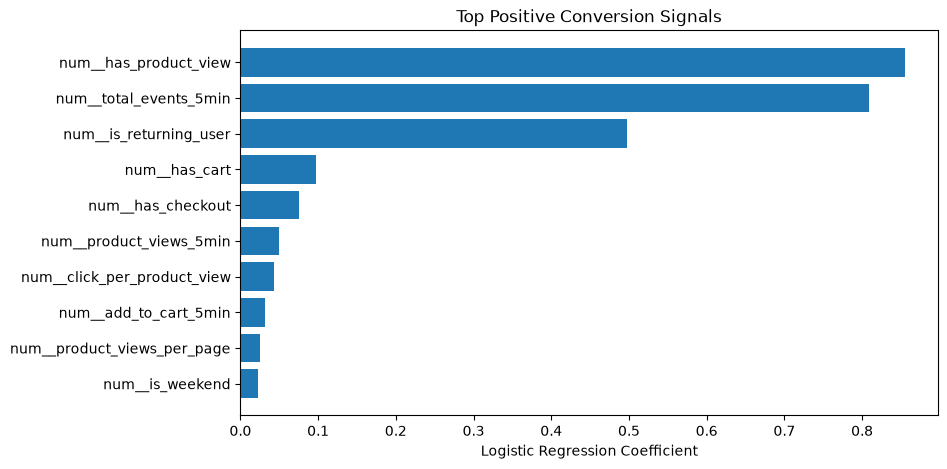

In [46]:
top_positive = coef_df.head(10)

plt.figure(figsize=(9, 5))

plt.barh(
    top_positive["feature"],
    top_positive["coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.title("Top Positive Conversion Signals")
plt.gca().invert_yaxis()

plt.show()

In [45]:
import matplotlib.pyplot as plt

In [47]:
print("Top positive features:")
display(coef_df.head(10))

print("\nTop negative features:")
display(coef_df.tail(10).sort_values("coefficient"))

Top positive features:


,feature,coefficient
10,num__has_product_view,0.854795
0,num__total_events_5min,0.808379
7,num__is_returning_user,0.497057
8,num__has_cart,0.096944
9,num__has_checkout,0.075621
2,num__product_views_5min,0.049151
13,num__click_per_product_view,0.043442
4,num__add_to_cart_5min,0.031649
12,num__product_views_per_page,0.025064
15,num__is_weekend,0.022850



Top negative features:


,feature,coefficient
16,cat__device_category_desktop,-1.096759
17,cat__device_category_mobile,-1.005280
18,cat__device_category_tablet,-0.966307
28,cat__traffic_source_google,-0.724448
20,cat__operating_system_Android,-0.652428
27,cat__traffic_source_<Other>,-0.643287
26,cat__traffic_source_(direct),-0.603386
31,cat__traffic_medium_(none),-0.603386
30,cat__traffic_medium_(data deleted),-0.598868
35,cat__traffic_medium_referral,-0.585370


In [48]:
logistic_results = {
    "Model": "Logistic Regression",
    "ROC_AUC": roc_auc,
    "PR_AUC": pr_auc,
    "Log_Loss": logloss,
    "Brier_Score": brier,
    "Lift_10": lift_at_10
}

logistic_results

{'Model': 'Logistic Regression',
 'ROC_AUC': 0.9518403354333846,
 'PR_AUC': 0.2722671853557379,
 'Log_Loss': 0.030549584670709052,
 'Brier_Score': 0.0074765947372320155,
 'Lift_10': np.float64(8.91104188198816)}

# Now train Random Forest using the same train and validation sets.

In [49]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=10,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
])

random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed.")

Random Forest training completed.


In [50]:
rf_val_prob = random_forest_model.predict_proba(
    X_val
)[:, 1]

In [51]:
rf_roc_auc = roc_auc_score(
    y_val,
    rf_val_prob
)

rf_pr_auc = average_precision_score(
    y_val,
    rf_val_prob
)

rf_logloss = log_loss(
    y_val,
    rf_val_prob
)

rf_brier = brier_score_loss(
    y_val,
    rf_val_prob
)

print(f"ROC-AUC: {rf_roc_auc:.4f}")
print(f"PR-AUC: {rf_pr_auc:.4f}")
print(f"Log Loss: {rf_logloss:.4f}")
print(f"Brier Score: {rf_brier:.4f}")

ROC-AUC: 0.9517
PR-AUC: 0.2702
Log Loss: 0.2142
Brier Score: 0.0589


In [52]:
rf_lift_table = calculate_lift_table(
    y_val,
    rf_val_prob,
    [0.01, 0.05, 0.10, 0.20, 0.30]
)

rf_lift_table

,Top_Percent,Sessions_Targeted,Conversion_Rate_%,Recall_%,Lift
0,1.0,835,30.778443,35.013624,35.025784
1,5.0,4176,13.960728,79.427793,15.887270
2,10.0,8352,7.878352,89.645777,8.965544
3,20.0,16705,4.136486,94.141689,4.707310
4,30.0,25058,2.817463,96.185286,3.206266


In [53]:
print(f"ROC-AUC: {rf_roc_auc:.4f}")
print(f"PR-AUC: {rf_pr_auc:.4f}")
print(f"Log Loss: {rf_logloss:.4f}")
print(f"Brier Score: {rf_brier:.4f}")

ROC-AUC: 0.9517
PR-AUC: 0.2702
Log Loss: 0.2142
Brier Score: 0.0589


In [54]:
rf_unweighted = Pipeline([
    ("preprocessor", preprocessor),

    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1
        )
    )
])

rf_unweighted.fit(
    X_train,
    y_train
)

rf2_val_prob = rf_unweighted.predict_proba(
    X_val
)[:, 1]

In [55]:
print(
    "ROC-AUC:",
    round(
        roc_auc_score(y_val, rf2_val_prob),
        4
    )
)

print(
    "PR-AUC:",
    round(
        average_precision_score(y_val, rf2_val_prob),
        4
    )
)

print(
    "Log Loss:",
    round(
        log_loss(y_val, rf2_val_prob),
        4
    )
)

print(
    "Brier Score:",
    round(
        brier_score_loss(y_val, rf2_val_prob),
        4
    )
)

ROC-AUC: 0.9545
PR-AUC: 0.2882
Log Loss: 0.0298
Brier Score: 0.0073


In [56]:
rf2_lift_table = calculate_lift_table(
    y_val,
    rf2_val_prob,
    [0.01, 0.05, 0.10, 0.20, 0.30]
)

rf2_lift_table

,Top_Percent,Sessions_Targeted,Conversion_Rate_%,Recall_%,Lift
0,1.0,835,32.814371,37.329700,37.342665
1,5.0,4176,13.960728,79.427793,15.887270
2,10.0,8352,7.962165,90.599455,9.060922
3,20.0,16705,4.136486,94.141689,4.707310
4,30.0,25058,2.829436,96.594005,3.219890


# move to XGBoost.

In [57]:
from xgboost import XGBClassifier

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        XGBClassifier(
            n_estimators=400,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )
    )
])

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training completed.")

XGBoost training completed.


In [58]:
xgb_val_prob = xgb_model.predict_proba(
    X_val
)[:, 1]

In [59]:
xgb_roc_auc = roc_auc_score(
    y_val,
    xgb_val_prob
)

xgb_pr_auc = average_precision_score(
    y_val,
    xgb_val_prob
)

xgb_logloss = log_loss(
    y_val,
    xgb_val_prob
)

xgb_brier = brier_score_loss(
    y_val,
    xgb_val_prob
)

print(f"ROC-AUC: {xgb_roc_auc:.4f}")
print(f"PR-AUC: {xgb_pr_auc:.4f}")
print(f"Log Loss: {xgb_logloss:.4f}")
print(f"Brier Score: {xgb_brier:.4f}")

ROC-AUC: 0.9526
PR-AUC: 0.2591
Log Loss: 0.0303
Brier Score: 0.0076


In [60]:
xgb_lift_table = calculate_lift_table(
    y_val,
    xgb_val_prob,
    [0.01, 0.05, 0.10, 0.20, 0.30]
)

xgb_lift_table

,Top_Percent,Sessions_Targeted,Conversion_Rate_%,Recall_%,Lift
0,1.0,835,29.820359,33.923706,33.935488
1,5.0,4176,13.864943,78.882834,15.778267
2,10.0,8352,7.926245,90.190736,9.020045
3,20.0,16705,4.148459,94.414169,4.720935
4,30.0,25058,2.829436,96.594005,3.219890


In [61]:
from xgboost import XGBClassifier

xgb_tuned = Pipeline([
    ("preprocessor", preprocessor),

    (
        "classifier",
        XGBClassifier(
            n_estimators=700,
            max_depth=3,
            learning_rate=0.03,
            min_child_weight=5,

            subsample=0.8,
            colsample_bytree=0.8,

            reg_alpha=0.1,
            reg_lambda=2.0,

            objective="binary:logistic",
            eval_metric="logloss",

            random_state=42,
            n_jobs=-1
        )
    )
])

xgb_tuned.fit(X_train, y_train)

xgb_tuned_prob = xgb_tuned.predict_proba(X_val)[:, 1]

In [62]:
tuned_roc = roc_auc_score(y_val, xgb_tuned_prob)

tuned_pr = average_precision_score(
    y_val,
    xgb_tuned_prob
)

tuned_logloss = log_loss(
    y_val,
    xgb_tuned_prob
)

tuned_brier = brier_score_loss(
    y_val,
    xgb_tuned_prob
)

print(f"ROC-AUC: {tuned_roc:.4f}")
print(f"PR-AUC: {tuned_pr:.4f}")
print(f"Log Loss: {tuned_logloss:.4f}")
print(f"Brier Score: {tuned_brier:.4f}")

ROC-AUC: 0.9544
PR-AUC: 0.2853
Log Loss: 0.0297
Brier Score: 0.0074


In [63]:
xgb_tuned_lift = calculate_lift_table(
    y_val,
    xgb_tuned_prob,
    [0.01, 0.05, 0.10, 0.20, 0.30]
)

xgb_tuned_lift

,Top_Percent,Sessions_Targeted,Conversion_Rate_%,Recall_%,Lift
0,1.0,835,32.455090,36.920981,36.933804
1,5.0,4176,14.008621,79.700272,15.941772
2,10.0,8352,7.938218,90.326975,9.033671
3,20.0,16705,4.136486,94.141689,4.707310
4,30.0,25058,2.837417,96.866485,3.228973


In [64]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Tuned XGBoost"
    ],

    "ROC_AUC": [
        0.9518,
        0.9545,
        0.9526,
        0.9544
    ],

    "PR_AUC": [
        0.2723,
        0.2882,
        0.2591,
        0.2853
    ],

    "Log_Loss": [
        0.0305,
        0.0298,
        0.0303,
        0.0297
    ],

    "Brier": [
        0.0075,
        0.0073,
        0.0076,
        0.0074
    ]
})

model_comparison

,Model,ROC_AUC,PR_AUC,Log_Loss,Brier
0,Logistic Regression,0.9518,0.2723,0.0305,0.0075
1,Random Forest,0.9545,0.2882,0.0298,0.0073
2,XGBoost,0.9526,0.2591,0.0303,0.0076
3,Tuned XGBoost,0.9544,0.2853,0.0297,0.0074


In [65]:
def get_lift(y_true, probabilities, pct):

    temp = pd.DataFrame({
        "actual": np.asarray(y_true),
        "probability": probabilities
    }).sort_values(
        "probability",
        ascending=False
    )

    n = int(len(temp) * pct)

    selected = temp.head(n)

    baseline_rate = temp["actual"].mean()
    selected_rate = selected["actual"].mean()

    lift = selected_rate / baseline_rate

    recall = (
        selected["actual"].sum()
        / temp["actual"].sum()
    )

    return lift, recall

In [66]:
models_probs = {
    "Logistic Regression": val_prob,
    "Random Forest": rf2_val_prob,
    "XGBoost": xgb_val_prob,
    "Tuned XGBoost": xgb_tuned_prob
}

business_results = []

for model_name, prob in models_probs.items():

    lift5, recall5 = get_lift(
        y_val, prob, 0.05
    )

    lift10, recall10 = get_lift(
        y_val, prob, 0.10
    )

    business_results.append({
        "Model": model_name,
        "Lift@5%": lift5,
        "Recall@5%": recall5 * 100,
        "Lift@10%": lift10,
        "Recall@10%": recall10 * 100
    })

business_comparison = pd.DataFrame(
    business_results
)

business_comparison.round(3)

,Model,Lift@5%,Recall@5%,Lift@10%,Recall@10%
0,Logistic Regression,15.533,77.657,8.911,89.101
1,Random Forest,15.887,79.428,9.061,90.599
2,XGBoost,15.778,78.883,9.020,90.191
3,Tuned XGBoost,15.942,79.700,9.034,90.327


In [67]:
calibration_train = validation[
    validation["session_date"] <= "2020-12-27"
].copy()

calibration_check = validation[
    validation["session_date"] > "2020-12-27"
].copy()

print(
    calibration_train.shape,
    calibration_check.shape
)

(44608, 28) (38921, 28)


In [68]:
X_cal_train = calibration_train[
    feature_columns
]

y_cal_train = calibration_train[
    "target"
]

X_cal_check = calibration_check[
    feature_columns
]

y_cal_check = calibration_check[
    "target"
]

In [69]:
rf_cal_train_prob = (
    rf_unweighted
    .predict_proba(X_cal_train)[:, 1]
)

rf_cal_check_prob = (
    rf_unweighted
    .predict_proba(X_cal_check)[:, 1]
)

In [70]:
from sklearn.linear_model import LogisticRegression

platt = LogisticRegression()

platt.fit(
    rf_cal_train_prob.reshape(-1, 1),
    y_cal_train
)

platt_prob = platt.predict_proba(
    rf_cal_check_prob.reshape(-1, 1)
)[:, 1]

In [71]:
from sklearn.isotonic import IsotonicRegression

isotonic = IsotonicRegression(
    out_of_bounds="clip"
)

isotonic.fit(
    rf_cal_train_prob,
    y_cal_train
)

isotonic_prob = isotonic.predict(
    rf_cal_check_prob
)

In [72]:
calibration_results = pd.DataFrame({
    "Model": [
        "Raw Random Forest",
        "Platt",
        "Isotonic"
    ],

    "Log_Loss": [
        log_loss(
            y_cal_check,
            rf_cal_check_prob
        ),
        log_loss(
            y_cal_check,
            platt_prob
        ),
        log_loss(
            y_cal_check,
            isotonic_prob
        )
    ],

    "Brier": [
        brier_score_loss(
            y_cal_check,
            rf_cal_check_prob
        ),
        brier_score_loss(
            y_cal_check,
            platt_prob
        ),
        brier_score_loss(
            y_cal_check,
            isotonic_prob
        )
    ]
})

calibration_results

,Model,Log_Loss,Brier
0,Raw Random Forest,0.020984,0.004840
1,Platt,0.023422,0.004739
2,Isotonic,0.019924,0.004616


## 1. Fit isotonic calibration using the full validation set

In [73]:
from sklearn.isotonic import IsotonicRegression

# Raw RF probabilities on full validation set
rf_val_prob_final = rf_unweighted.predict_proba(
    X_val
)[:, 1]

# Fit final calibrator
final_isotonic = IsotonicRegression(
    out_of_bounds="clip"
)

final_isotonic.fit(
    rf_val_prob_final,
    y_val
)

print("Final isotonic calibrator fitted.")

Final isotonic calibrator fitted.


In [74]:
# Raw Random Forest test probabilities
rf_test_raw_prob = rf_unweighted.predict_proba(
    X_test
)[:, 1]

# Calibrated test probabilities
rf_test_calibrated_prob = final_isotonic.predict(
    rf_test_raw_prob
)

In [75]:
test_roc = roc_auc_score(
    y_test,
    rf_test_calibrated_prob
)

test_pr = average_precision_score(
    y_test,
    rf_test_calibrated_prob
)

test_logloss = log_loss(
    y_test,
    rf_test_calibrated_prob
)

test_brier = brier_score_loss(
    y_test,
    rf_test_calibrated_prob
)

print(f"Test ROC-AUC: {test_roc:.4f}")
print(f"Test PR-AUC: {test_pr:.4f}")
print(f"Test Log Loss: {test_logloss:.4f}")
print(f"Test Brier Score: {test_brier:.4f}")

Test ROC-AUC: 0.9520
Test PR-AUC: 0.2577
Test Log Loss: 0.0314
Test Brier Score: 0.0076


In [76]:
print(
    f"Test Conversion Rate: "
    f"{y_test.mean() * 100:.3f}%"
)

Test Conversion Rate: 0.930%


In [77]:
test_lift_table = calculate_lift_table(
    y_test,
    rf_test_calibrated_prob,
    [0.01, 0.05, 0.10, 0.20, 0.30]
)

test_lift_table

,Top_Percent,Sessions_Targeted,Conversion_Rate_%,Recall_%,Lift
0,1.0,919,33.514690,36.023392,36.033583
1,5.0,4596,14.425587,77.543860,15.509784
2,10.0,9192,8.202785,88.187135,8.819289
3,20.0,18385,4.340495,93.333333,4.666717
4,30.0,27577,2.937230,94.736842,3.157986


# Use the raw Random Forest score for ranking and the isotonic probability for the customer-facing probability estimate

In [78]:
test_results = pd.DataFrame({
    "actual_purchase": y_test.values,
    "raw_score": rf_test_raw_prob,
    "purchase_probability": rf_test_calibrated_prob
})

test_results["rank_percentile"] = (
    test_results["raw_score"]
    .rank(
        method="first",
        ascending=False,
        pct=True
    )
)

test_results["intent_segment"] = np.select(
    [
        test_results["rank_percentile"] <= 0.05,
        test_results["rank_percentile"] <= 0.20
    ],
    [
        "High Intent",
        "Medium Intent"
    ],
    default="Low Intent"
)

test_results.head()

,actual_purchase,raw_score,purchase_probability,rank_percentile,intent_segment
0,0,0.004959,0.002268,0.206644,Low Intent
1,0,0.003625,0.002268,0.306551,Low Intent
2,0,0.001395,0.000748,0.513206,Low Intent
3,0,0.232701,0.177305,0.014425,High Intent
4,0,0.005304,0.002882,0.188086,Medium Intent


In [79]:
segment_summary = (
    test_results
    .groupby("intent_segment")
    .agg(
        sessions=("actual_purchase", "size"),
        conversions=("actual_purchase", "sum"),
        conversion_rate=("actual_purchase", "mean"),
        avg_predicted_probability=(
            "purchase_probability",
            "mean"
        )
    )
)

segment_summary["conversion_rate"] *= 100
segment_summary["avg_predicted_probability"] *= 100

segment_summary

,sessions,conversions,conversion_rate,avg_predicted_probability
intent_segment,,,,
High Intent,4596,664,14.447346,12.928111
Low Intent,73541,57,0.077508,0.089116
Medium Intent,13789,134,0.971789,0.986399


In [80]:
segment_calibration = (
    test_results
    .groupby("intent_segment")
    .agg(
        actual_conversion_rate=(
            "actual_purchase",
            "mean"
        ),
        predicted_conversion_rate=(
            "purchase_probability",
            "mean"
        )
    )
    * 100
)

segment_calibration

,actual_conversion_rate,predicted_conversion_rate
intent_segment,,
High Intent,14.447346,12.928111
Low Intent,0.077508,0.089116
Medium Intent,0.971789,0.986399


In [81]:
segment_business = (
    test_results
    .groupby("intent_segment")
    .agg(
        sessions=("actual_purchase", "size"),
        purchases=("actual_purchase", "sum"),
        actual_conversion_rate=(
            "actual_purchase",
            "mean"
        ),
        avg_predicted_probability=(
            "purchase_probability",
            "mean"
        )
    )
)

segment_business[
    "actual_conversion_rate"
] *= 100

segment_business[
    "avg_predicted_probability"
] *= 100

segment_business

,sessions,purchases,actual_conversion_rate,avg_predicted_probability
intent_segment,,,,
High Intent,4596,664,14.447346,12.928111
Low Intent,73541,57,0.077508,0.089116
Medium Intent,13789,134,0.971789,0.986399


In [82]:
segment_business["session_share_%"] = (
    segment_business["sessions"]
    / segment_business["sessions"].sum()
    * 100
)

segment_business

,sessions,purchases,actual_conversion_rate,avg_predicted_probability,session_share_%
intent_segment,,,,,
High Intent,4596,664,14.447346,12.928111,4.999674
Low Intent,73541,57,0.077508,0.089116,80.000218
Medium Intent,13789,134,0.971789,0.986399,15.000109


In [83]:
segment_business["purchase_share_%"] = (
    segment_business["purchases"]
    / segment_business["purchases"].sum()
    * 100
)

segment_business["calibration_gap_pp"] = (
    segment_business["avg_predicted_probability"]
    - segment_business["actual_conversion_rate"]
)

segment_business[
    [
        "sessions",
        "purchases",
        "session_share_%",
        "purchase_share_%",
        "actual_conversion_rate",
        "avg_predicted_probability",
        "calibration_gap_pp"
    ]
]

,sessions,purchases,session_share_%,purchase_share_%,actual_conversion_rate,avg_predicted_probability,calibration_gap_pp
intent_segment,,,,,,,
High Intent,4596,664,4.999674,77.660819,14.447346,12.928111,-1.519235
Low Intent,73541,57,80.000218,6.666667,0.077508,0.089116,0.011608
Medium Intent,13789,134,15.000109,15.672515,0.971789,0.986399,0.01461


In [84]:
gross_margin_per_order = 600   # ₹
discount_per_order = 100       # ₹
campaign_cost_per_session = 2  # ₹

In [85]:
def simulate_campaign(
    sessions,
    baseline_conversion,
    uplift_pp,
    gross_margin,
    discount,
    campaign_cost
):
    
    new_conversion = min(
        baseline_conversion + uplift_pp / 100,
        1
    )

    baseline_orders = (
        sessions * baseline_conversion
    )

    campaign_orders = (
        sessions * new_conversion
    )

    baseline_profit = (
        baseline_orders * gross_margin
    )

    campaign_profit = (
        campaign_orders
        * (gross_margin - discount)
        - sessions * campaign_cost
    )

    incremental_profit = (
        campaign_profit - baseline_profit
    )

    return {
        "baseline_orders": baseline_orders,
        "campaign_orders": campaign_orders,
        "baseline_profit": baseline_profit,
        "campaign_profit": campaign_profit,
        "incremental_profit": incremental_profit
    }

In [86]:
medium = segment_business.loc["Medium Intent"]

medium_result = simulate_campaign(
    sessions=medium["sessions"],
    baseline_conversion=(
        medium["actual_conversion_rate"] / 100
    ),
    uplift_pp=1.0,   # hypothetical +1 percentage point
    gross_margin=600,
    discount=100,
    campaign_cost=2
)

medium_result

{'baseline_orders': np.float64(134.0),
 'campaign_orders': np.float64(271.89000000000004),
 'baseline_profit': np.float64(80400.0),
 'campaign_profit': np.float64(108367.00000000003),
 'incremental_profit': np.float64(27967.00000000003)}

In [87]:
uplift_scenarios = [
    0,
    0.25,
    0.50,
    0.75,
    1.00,
    1.50,
    2.00
]

rows = []

for uplift in uplift_scenarios:

    result = simulate_campaign(
        sessions=medium["sessions"],
        baseline_conversion=(
            medium["actual_conversion_rate"] / 100
        ),
        uplift_pp=uplift,
        gross_margin=600,
        discount=100,
        campaign_cost=2
    )

    rows.append({
        "uplift_pp": uplift,
        **result
    })

campaign_simulation = pd.DataFrame(rows)

campaign_simulation

,uplift_pp,baseline_orders,campaign_orders,baseline_profit,campaign_profit,incremental_profit
0,0.00,134.0,134.0000,80400.0,39422.00,-40978.00
1,0.25,134.0,168.4725,80400.0,56658.25,-23741.75
2,0.50,134.0,202.9450,80400.0,73894.50,-6505.50
3,0.75,134.0,237.4175,80400.0,91130.75,10730.75
4,1.00,134.0,271.8900,80400.0,108367.00,27967.00
5,1.50,134.0,340.8350,80400.0,142839.50,62439.50
6,2.00,134.0,409.7800,80400.0,177312.00,96912.00


In [88]:
baseline_rate = (
    medium["actual_conversion_rate"] / 100
)

break_even_uplift = (
    (
        discount_per_order * baseline_rate
        + campaign_cost_per_session
    )
    /
    (
        gross_margin_per_order
        - discount_per_order
    )
)

print(
    "Break-even uplift:",
    round(break_even_uplift * 100, 3),
    "percentage points"
)

break_even_conversion = (
    baseline_rate + break_even_uplift
)

print(
    "Break-even conversion rate:",
    round(break_even_conversion * 100, 3),
    "%"
)

additional_orders_needed = (
    medium["sessions"] * break_even_uplift
)

print(
    "Additional orders required:",
    round(additional_orders_needed, 1)
)

Break-even uplift: 0.594 percentage points
Break-even conversion rate: 1.566 %
Additional orders required: 82.0


In [1]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt